In [ ]:
# ============================================================
# BÀI 4 - GOM CỤM
# Dataset: UCI Human Activity Recognition
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Đã import thư viện thành công!")

Đã import thư viện thành công!


In [ ]:
# ============================================================
# KIỂM TRA CÁC FILE DỮ LIỆU ĐÃ TIỀN XỬ LÝ
# ============================================================

import os

processed_path = "../data/processed"

print("=== CÁC FILE TRONG DATA/PROCESSED ===")

for file in os.listdir(processed_path):
    print(file)

=== CÁC FILE TRONG DATA/PROCESSED ===
diabetes_processed.csv
har_processed.csv
retail_processed.csv


In [ ]:
# ============================================================
# CELL 3 - ĐỌC DATASET UCI HAR
# ============================================================

har = pd.read_csv("../data/processed/har_processed.csv")

print("=== THÔNG TIN DATASET ===")
print("Kích thước:", har.shape)
print("Số bản ghi:", har.shape[0])
print("Số thuộc tính:", har.shape[1])

print("\n=== 5 BẢN GHI ĐẦU ===")
display(har.head())

print("\n=== 5 CỘT CUỐI ===")
print(har.columns[-5:].tolist())

=== THÔNG TIN DATASET ===
Kích thước: (10299, 563)
Số bản ghi: 10299
Số thuộc tính: 563

=== 5 BẢN GHI ĐẦU ===


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",activity_id,activity_name
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,5,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,5,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,5,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,5,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,5,STANDING



=== 5 CỘT CUỐI ===
['angle(X,gravityMean)', 'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'activity_id', 'activity_name']


In [ ]:
# ============================================================
# CELL 4 - TÁCH DỮ LIỆU VÀ CHUẨN HÓA
# ============================================================

# Loại 2 cột nhãn khỏi dữ liệu dùng để gom cụm
X = har.drop(columns=["activity_id", "activity_name"])

# Giữ nhãn thật để đối chiếu sau khi gom cụm
y_activity = har["activity_name"].copy()

print("=== DỮ LIỆU DÙNG ĐỂ GOM CỤM ===")
print("Kích thước X:", X.shape)
print("Số thuộc tính:", X.shape[1])

print("\n=== PHÂN BỐ HOẠT ĐỘNG THỰC TẾ ===")
print(y_activity.value_counts())

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n=== SAU CHUẨN HÓA ===")
print("Kích thước:", X_scaled.shape)
print("Mean:", round(X_scaled.mean(), 6))
print("Std :", round(X_scaled.std(), 6))
print("Có NaN:", np.isnan(X_scaled).any())
print("Có Inf:", np.isinf(X_scaled).any())

=== DỮ LIỆU DÙNG ĐỂ GOM CỤM ===
Kích thước X: (10299, 561)
Số thuộc tính: 561

=== PHÂN BỐ HOẠT ĐỘNG THỰC TẾ ===
activity_name
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

=== SAU CHUẨN HÓA ===
Kích thước: (10299, 561)
Mean: 0.0
Std : 1.0
Có NaN: False
Có Inf: False


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

print("StandardScaler đã sẵn sàng!")

StandardScaler đã sẵn sàng!


In [ ]:
# ============================================================
# CELL 5 - CHỌN SỐ CỤM K
# Elbow Method + Silhouette Score
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(2, 9)

inertias = []
silhouette_scores = []

print("=== ĐÁNH GIÁ SỐ CỤM K ===")

for k in k_values:
    print(f"Đang chạy K = {k}...")

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia = model.inertia_

    # Lấy mẫu để tính nhanh Silhouette
    sil_score = silhouette_score(
        X_scaled,
        labels,
        sample_size=3000,
        random_state=42
    )

    inertias.append(inertia)
    silhouette_scores.append(sil_score)

    print(
        f"K={k} | "
        f"Inertia={inertia:.2f} | "
        f"Silhouette={sil_score:.4f}"
    )

print("\nHoàn thành đánh giá K!")

=== ĐÁNH GIÁ SỐ CỤM K ===
Đang chạy K = 2...
K=2 | Inertia=3272856.62 | Silhouette=0.3955
Đang chạy K = 3...
K=3 | Inertia=2921077.60 | Silhouette=0.3130
Đang chạy K = 4...
K=4 | Inertia=2781602.14 | Silhouette=0.1510
Đang chạy K = 5...
K=5 | Inertia=2654789.79 | Silhouette=0.1317
Đang chạy K = 6...
K=6 | Inertia=2577180.43 | Silhouette=0.1096
Đang chạy K = 7...
K=7 | Inertia=2519774.22 | Silhouette=0.0798
Đang chạy K = 8...
K=8 | Inertia=2465378.96 | Silhouette=0.0743

Hoàn thành đánh giá K!


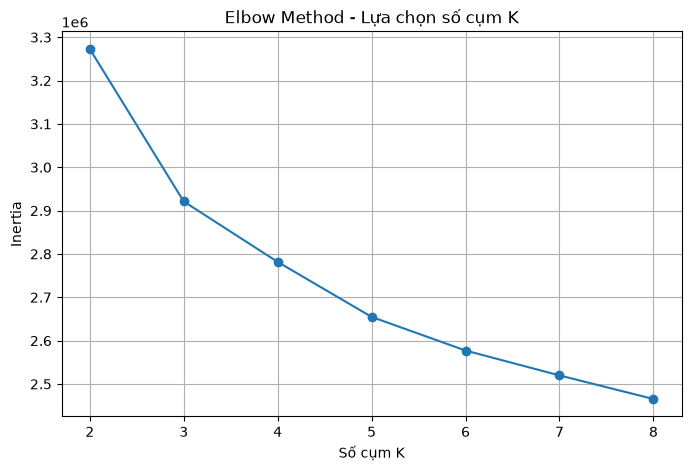

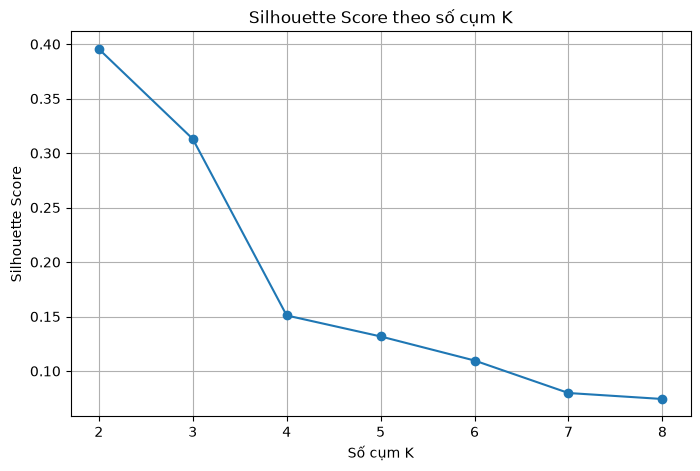

=== KẾT QUẢ LỰA CHỌN K ===
K có Silhouette cao nhất: 2
Silhouette cao nhất: 0.3955


In [ ]:
# ============================================================
# CELL 6 - TRỰC QUAN HÓA LỰA CHỌN SỐ CỤM K
# ============================================================

# Biểu đồ Elbow
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.xlabel("Số cụm K")
plt.ylabel("Inertia")
plt.title("Elbow Method - Lựa chọn số cụm K")
plt.grid(True)
plt.show()

# Biểu đồ Silhouette
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores, marker="o")
plt.xlabel("Số cụm K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score theo số cụm K")
plt.grid(True)
plt.show()

# K có Silhouette cao nhất
best_k = list(k_values)[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print("=== KẾT QUẢ LỰA CHỌN K ===")
print("K có Silhouette cao nhất:", best_k)
print("Silhouette cao nhất:", round(best_score, 4))

### Nhận xét lựa chọn số cụm

Thử nghiệm K-Means với số cụm từ 2 đến 8 cho thấy Inertia giảm dần khi số cụm tăng. Điều này phù hợp với đặc điểm của thuật toán K-Means khi tăng số lượng cụm.

Silhouette Score đạt giá trị cao nhất tại **K = 2**, với giá trị khoảng **0.3955**. Khi tăng số cụm từ 3 đến 8, Silhouette Score giảm dần, cho thấy mức độ tách biệt giữa các cụm kém hơn.

Vì vậy, dựa trên Silhouette Score, **K = 2 được lựa chọn** để xây dựng mô hình K-Means chính thức.

In [ ]:
# ============================================================
# CELL 7 - MÔ HÌNH K-MEANS CHÍNH THỨC
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

# Đánh giá
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels,
    sample_size=3000,
    random_state=42
)

kmeans_db = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

print("=== K-MEANS - K = 2 ===")
print("Silhouette Score    :", round(kmeans_silhouette, 4))
print("Davies-Bouldin Index:", round(kmeans_db, 4))

# Phân bố số lượng phần tử trong từng cụm
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

print("\n=== PHÂN BỐ CỤM ===")
for cluster, count in cluster_counts.items():
    print(
        f"Cụm {cluster}: {count} bản ghi "
        f"({count / len(kmeans_labels) * 100:.2f}%)"
    )

=== K-MEANS - K = 2 ===
Silhouette Score    : 0.3955
Davies-Bouldin Index: 1.0707

=== PHÂN BỐ CỤM ===
Cụm 0: 5620 bản ghi (54.57%)
Cụm 1: 4679 bản ghi (45.43%)


In [ ]:
# ============================================================
# CELL 8 - ĐỐI CHIẾU CỤM VỚI HOẠT ĐỘNG THỰC TẾ
# ============================================================

cluster_analysis = pd.DataFrame({
    "cluster": kmeans_labels,
    "activity": y_activity
})

cluster_activity = pd.crosstab(
    cluster_analysis["cluster"],
    cluster_analysis["activity"]
)

print("=== HOẠT ĐỘNG TRONG TỪNG CỤM ===")
display(cluster_activity)

print("\n=== TỶ LỆ HOẠT ĐỘNG TRONG TỪNG CỤM (%) ===")

cluster_activity_pct = pd.crosstab(
    cluster_analysis["cluster"],
    cluster_analysis["activity"],
    normalize="index"
) * 100

display(cluster_activity_pct.round(2))

=== HOẠT ĐỘNG TRONG TỪNG CỤM ===


activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
cluster,,,,,,
0,1932,1774,1906,0,0,8
1,12,3,0,1722,1406,1536



=== TỶ LỆ HOẠT ĐỘNG TRONG TỪNG CỤM (%) ===


activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
cluster,,,,,,
0,34.38,31.57,33.91,0.0,0.00,0.14
1,0.26,0.06,0.00,36.8,30.05,32.83


In [ ]:
# ============================================================
# CELL 9 - AGGLOMERATIVE CLUSTERING
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time

print("Đang chạy Agglomerative Clustering...")

start_time = time.time()

agg_model = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

agg_labels = agg_model.fit_predict(X_scaled)

agg_time = time.time() - start_time

# Đánh giá
agg_silhouette = silhouette_score(
    X_scaled,
    agg_labels,
    sample_size=3000,
    random_state=42
)

agg_db = davies_bouldin_score(
    X_scaled,
    agg_labels
)

print("\n=== AGGLOMERATIVE CLUSTERING - K = 2 ===")
print("Silhouette Score     :", round(agg_silhouette, 4))
print("Davies-Bouldin Index :", round(agg_db, 4))
print("Thời gian chạy       :", round(agg_time, 2), "giây")

print("\n=== PHÂN BỐ CỤM ===")

agg_counts = pd.Series(agg_labels).value_counts().sort_index()

for cluster, count in agg_counts.items():
    print(
        f"Cụm {cluster}: {count} bản ghi "
        f"({count / len(agg_labels) * 100:.2f}%)"
    )

Đang chạy Agglomerative Clustering...

=== AGGLOMERATIVE CLUSTERING - K = 2 ===
Silhouette Score     : 0.3953
Davies-Bouldin Index : 1.0717
Thời gian chạy       : 32.72 giây

=== PHÂN BỐ CỤM ===
Cụm 0: 4672 bản ghi (45.36%)
Cụm 1: 5627 bản ghi (54.64%)


=== SO SÁNH HAI THUẬT TOÁN ===


,Thuật toán,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.3955,1.0707
1,Agglomerative Clustering,0.3953,1.0717


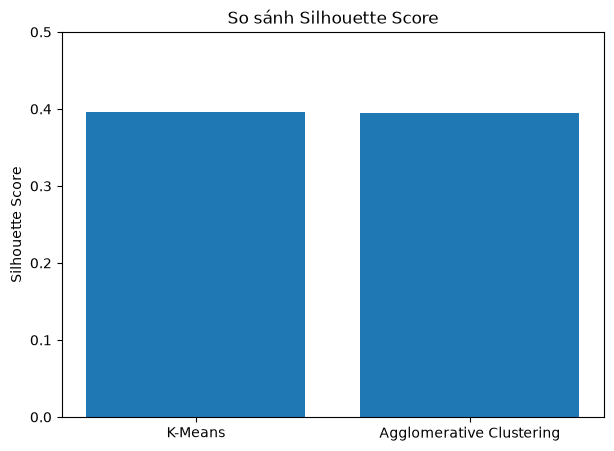

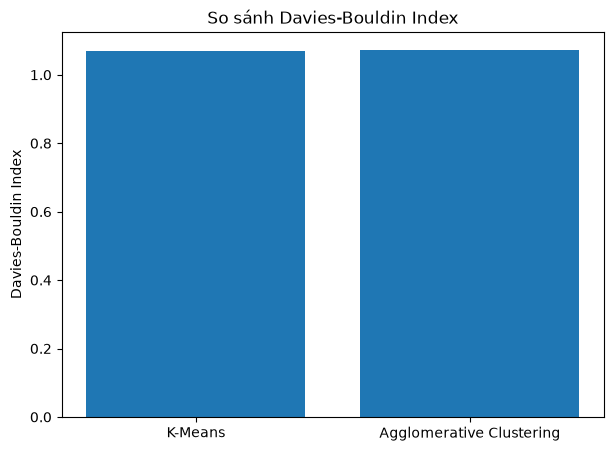

In [ ]:
# ============================================================
# CELL 10 - SO SÁNH HAI THUẬT TOÁN GOM CỤM
# ============================================================

comparison = pd.DataFrame({
    "Thuật toán": [
        "K-Means",
        "Agglomerative Clustering"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        agg_silhouette
    ],
    "Davies-Bouldin Index": [
        kmeans_db,
        agg_db
    ]
})

print("=== SO SÁNH HAI THUẬT TOÁN ===")
display(comparison.round(4))

# Biểu đồ Silhouette Score
plt.figure(figsize=(7, 5))
plt.bar(
    comparison["Thuật toán"],
    comparison["Silhouette Score"]
)

plt.ylabel("Silhouette Score")
plt.title("So sánh Silhouette Score")
plt.ylim(0, 0.5)
plt.show()

# Biểu đồ Davies-Bouldin Index
plt.figure(figsize=(7, 5))
plt.bar(
    comparison["Thuật toán"],
    comparison["Davies-Bouldin Index"]
)

plt.ylabel("Davies-Bouldin Index")
plt.title("So sánh Davies-Bouldin Index")
plt.show()

=== PCA ===
Kích thước sau PCA: (10299, 2)
Tỷ lệ phương sai giải thích: 56.98 %


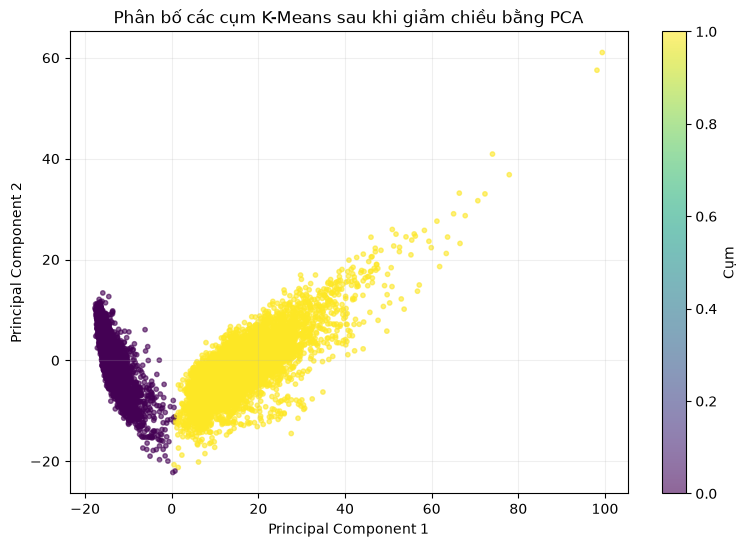

In [ ]:
# ============================================================
# CELL 11 - TRỰC QUAN HÓA CỤM BẰNG PCA
# ============================================================

from sklearn.decomposition import PCA

# Giảm 561 chiều xuống 2 chiều
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("=== PCA ===")
print("Kích thước sau PCA:", X_pca.shape)
print(
    "Tỷ lệ phương sai giải thích:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

# Vẽ kết quả K-Means
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=10,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Phân bố các cụm K-Means sau khi giảm chiều bằng PCA")

plt.colorbar(scatter, label="Cụm")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# ============================================================
# CELL 12 - PROFILING CÁC CỤM K-MEANS
# ============================================================

profile_df = pd.DataFrame({
    "cluster": kmeans_labels,
    "activity": y_activity
})

# Số lượng hoạt động trong từng cụm
profile_count = pd.crosstab(
    profile_df["cluster"],
    profile_df["activity"]
)

# Tỷ lệ %
profile_pct = pd.crosstab(
    profile_df["cluster"],
    profile_df["activity"],
    normalize="index"
) * 100

print("=== SỐ LƯỢNG THEO HOẠT ĐỘNG ===")
display(profile_count)

print("\n=== TỶ LỆ HOẠT ĐỘNG TRONG TỪNG CỤM (%) ===")
display(profile_pct.round(2))

# ------------------------------------------------------------
# Gộp thành nhóm hoạt động tĩnh / vận động
# ------------------------------------------------------------

static_activities = [
    "LAYING",
    "SITTING",
    "STANDING"
]

dynamic_activities = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS"
]

profile_df["activity_group"] = profile_df["activity"].apply(
    lambda x: "Hoạt động tĩnh"
    if x in static_activities
    else "Hoạt động vận động"
)

group_profile = pd.crosstab(
    profile_df["cluster"],
    profile_df["activity_group"],
    normalize="index"
) * 100

print("\n=== PROFILING THEO NHÓM HOẠT ĐỘNG (%) ===")
display(group_profile.round(2))

=== SỐ LƯỢNG THEO HOẠT ĐỘNG ===


activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
cluster,,,,,,
0,1932,1774,1906,0,0,8
1,12,3,0,1722,1406,1536



=== TỶ LỆ HOẠT ĐỘNG TRONG TỪNG CỤM (%) ===


activity,LAYING,SITTING,STANDING,WALKING,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS
cluster,,,,,,
0,34.38,31.57,33.91,0.0,0.00,0.14
1,0.26,0.06,0.00,36.8,30.05,32.83



=== PROFILING THEO NHÓM HOẠT ĐỘNG (%) ===


activity_group,Hoạt động tĩnh,Hoạt động vận động
cluster,,
0,99.86,0.14
1,0.32,99.68


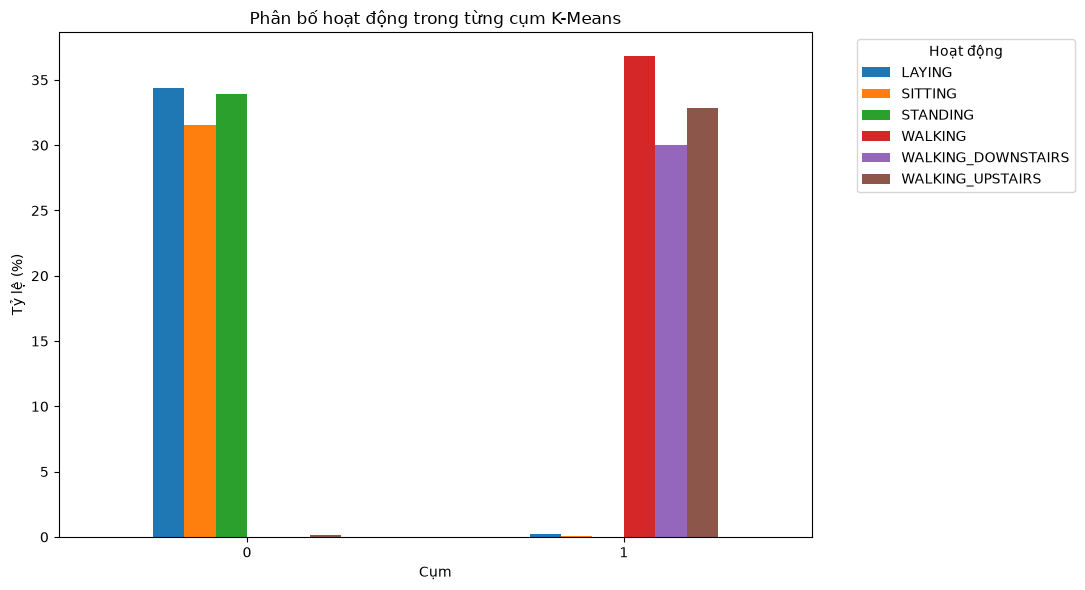

In [ ]:
# ============================================================
# CELL 13 - TRỰC QUAN HÓA PROFILING CỤM
# ============================================================

profile_pct.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Phân bố hoạt động trong từng cụm K-Means")
plt.xlabel("Cụm")
plt.ylabel("Tỷ lệ (%)")
plt.xticks(rotation=0)
plt.legend(title="Hoạt động", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Kết luận Bài 4 – Gom cụm

Trong bài thực hành, dữ liệu UCI Human Activity Recognition được sử dụng để thực hiện bài toán gom cụm với 561 thuộc tính đặc trưng.

### 1. Lựa chọn số cụm

Thử nghiệm K-Means với số cụm từ K = 2 đến K = 8 cho thấy K = 2 đạt Silhouette Score cao nhất, bằng 0.3955. Vì vậy, K = 2 được lựa chọn để xây dựng mô hình gom cụm.

### 2. So sánh thuật toán

Hai thuật toán được sử dụng gồm K-Means và Agglomerative Clustering.

- K-Means: Silhouette Score = 0.3955, Davies-Bouldin Index = 1.0707.
- Agglomerative Clustering: Silhouette Score = 0.3953, Davies-Bouldin Index = 1.0717.

Kết quả của hai thuật toán khá tương đồng. K-Means có Silhouette Score cao hơn nhẹ và Davies-Bouldin Index thấp hơn nhẹ.

### 3. Trực quan hóa bằng PCA

PCA được sử dụng để giảm dữ liệu từ 561 chiều xuống 2 chiều nhằm trực quan hóa kết quả gom cụm. Hai thành phần chính đầu tiên giải thích khoảng 56.98% phương sai của dữ liệu.

Biểu đồ PCA cho thấy hai cụm có sự phân tách tương đối rõ.

### 4. Profiling các cụm

Kết quả phân tích các hoạt động thực tế trong từng cụm cho thấy:

- Cụm 0 đại diện cho nhóm hoạt động tĩnh, gồm chủ yếu LAYING, SITTING và STANDING. Khoảng 99.86% các bản ghi trong cụm thuộc nhóm hoạt động tĩnh.
- Cụm 1 đại diện cho nhóm hoạt động vận động, gồm chủ yếu WALKING, WALKING_UPSTAIRS và WALKING_DOWNSTAIRS.

Như vậy, mặc dù thuật toán gom cụm không sử dụng nhãn hoạt động trong quá trình huấn luyện, kết quả vẫn tự động phân chia dữ liệu thành hai nhóm có ý nghĩa rõ ràng: hoạt động tĩnh và hoạt động vận động.

### 5. Kết luận

K-Means với K = 2 cho kết quả phù hợp đối với bộ dữ liệu được khảo sát. Hai cụm thu được có thể được diễn giải thành nhóm hoạt động tĩnh và nhóm hoạt động vận động. Kết quả cho thấy các đặc trưng cảm biến trong bộ dữ liệu có khả năng phân biệt tốt hai trạng thái hoạt động tổng quát của con người.